# Basic Self-Attention (NumPy) - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Implement tokenization, preprocessing, and a basic multi-head self-attention classifier using NumPy.

## 1) Imports and Setup

In [1]:
from __future__ import annotations

import importlib.util
import math
import os
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}

def load_runtime_env() -> None:
    env_files = [
        Path("configs/runtime.env"),
        Path("configs/runtime.env.example"),
        Path("../configs/runtime.env"),
        Path("../configs/runtime.env.example"),
    ]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

def register_local_module_path() -> None:
    candidates = [Path("."), Path("self-attention-variants"), Path("../self-attention-variants")]
    for candidate in candidates:
        if (candidate / "shared_text_preprocessing.py").exists():
            resolved = str(candidate.resolve())
            if resolved not in sys.path:
                sys.path.insert(0, resolved)
            return
    raise FileNotFoundError("Could not locate shared_text_preprocessing.py")

load_runtime_env()
register_local_module_path()
USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))
runtime_device = "cuda" if USE_GPU and importlib.util.find_spec("cupy") else "cpu"
print(f"USE_GPU={int(USE_GPU)} | runtime_device={runtime_device}")

from shared_text_preprocessing import PreprocessingConfig, prepare_text_data

USE_GPU=1 | runtime_device=cpu


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 256
    seq_len: int = 24
    d_model: int = 32
    num_heads: int = 4
    learning_rate: float = 0.2
    epochs: int = 120


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=256, seq_len=24, d_model=32, num_heads=4, learning_rate=0.2, epochs=120)

## 3) Data Loading

In [3]:
prep_cfg = PreprocessingConfig(
    num_samples=CFG.num_samples,
    seq_len=CFG.seq_len,
    max_vocab_size=2048,
    train_ratio=0.8,
)
data = prepare_text_data(prep_cfg, seed=SEED)
len(data.texts_train), len(data.texts_test), data.y_train.shape, data.y_test.shape

(204, 52, (204,), (52,))

## 4) EDA

In [4]:
train_lengths = np.array([len(text.split()) for text in data.texts_train], dtype=np.int64)
class_counts = np.bincount(np.concatenate([data.y_train, data.y_test]), minlength=2)
print("Class counts:", class_counts.tolist())
print("Train token-length mean/std:", float(train_lengths.mean()), float(train_lengths.std()))
print("Sample training sentence:", data.texts_train[0])

Class counts: [128, 128]
Train token-length mean/std: 8.0 0.0
Sample training sentence: service indicates reliable retrieval quality for multilingual traffic


## 5) Preprocessing / Feature Engineering

In [5]:
rng = np.random.default_rng(SEED)
emb_table = rng.normal(0.0, 0.2, (len(data.vocab), CFG.d_model)).astype(np.float32)
x_train = emb_table[data.train_token_ids]
x_test = emb_table[data.test_token_ids]
print({"vocab_size": len(data.vocab), "x_train_shape": tuple(x_train.shape), "x_test_shape": tuple(x_test.shape)})

{'vocab_size': 41, 'x_train_shape': (204, 24, 32), 'x_test_shape': (52, 24, 32)}


## 6) Model Definition

In [6]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def init_projection_weights(d_model: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w_q = rng.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_k = rng.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_v = rng.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    return w_q, w_k, w_v

def apply_qkv_projection(
    x: np.ndarray,
    w_q: np.ndarray,
    w_k: np.ndarray,
    w_v: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return x @ w_q, x @ w_k, x @ w_v

def multi_head_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray, num_heads: int) -> tuple[np.ndarray, np.ndarray]:
    batch, seq_len, d_model = q.shape
    if d_model % num_heads != 0:
        raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads}).")
    head_dim = d_model // num_heads
    qh = q.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    kh = k.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    vh = v.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    scores = (qh @ np.swapaxes(kh, -1, -2)) / math.sqrt(head_dim)
    weights = softmax(scores, axis=-1)
    out = weights @ vh
    out = out.transpose(0, 2, 1, 3).reshape(batch, seq_len, d_model)
    return out, weights

def pooled_features(attn_out: np.ndarray) -> np.ndarray:
    return attn_out.mean(axis=1)

## 7) Training

In [7]:
w_q, w_k, w_v = init_projection_weights(CFG.d_model)
q_train, k_train, v_train = apply_qkv_projection(x_train, w_q, w_k, w_v)
q_test, k_test, v_test = apply_qkv_projection(x_test, w_q, w_k, w_v)

attn_train, train_weights = multi_head_attention(q_train, k_train, v_train, CFG.num_heads)
x_feat_train = pooled_features(attn_train)

w = np.zeros((CFG.d_model, 1), dtype=np.float32)
b = np.zeros((1,), dtype=np.float32)
y_train_f = data.y_train.astype(np.float32).reshape(-1, 1)

for _ in range(CFG.epochs):
    logits = x_feat_train @ w + b
    probs = 1.0 / (1.0 + np.exp(-logits))
    error = probs - y_train_f
    grad_w = (x_feat_train.T @ error) / x_feat_train.shape[0]
    grad_b = error.mean(axis=0)
    w -= CFG.learning_rate * grad_w
    b -= CFG.learning_rate * grad_b

print("Training finished.")

Training finished.


## 8) Evaluation and Metrics

In [8]:
attn_test, test_weights = multi_head_attention(q_test, k_test, v_test, CFG.num_heads)
x_feat_test = pooled_features(attn_test)
logits_test = x_feat_test @ w + b
probs_test = 1.0 / (1.0 + np.exp(-logits_test))
preds_test = (probs_test >= 0.5).astype(np.int64).reshape(-1)
accuracy = float((preds_test == data.y_test).mean())
metrics = {"accuracy": accuracy}
metrics

{'accuracy': 0.6730769230769231}

## 9) Results Visualization

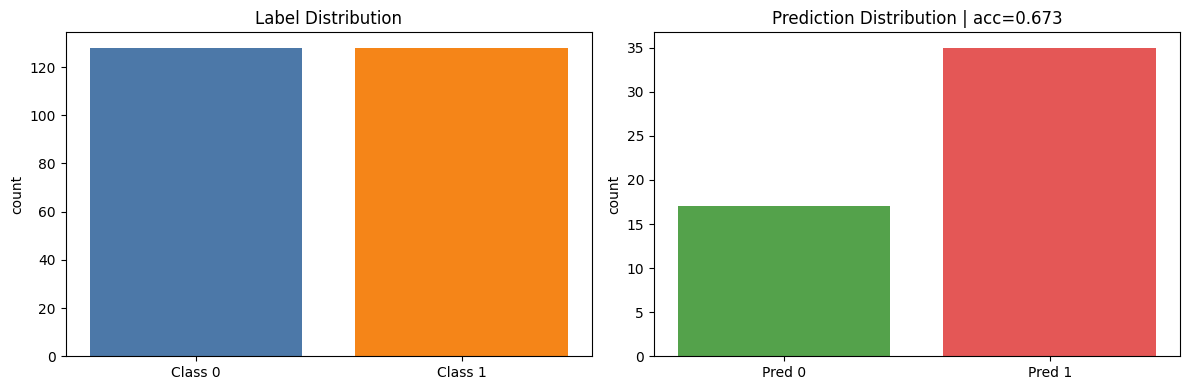

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Class 0", "Class 1"], class_counts, color=["#4C78A8", "#F58518"])
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("count")

pred_counts = np.bincount(preds_test, minlength=2)
axes[1].bar(["Pred 0", "Pred 1"], pred_counts, color=["#54A24B", "#E45756"])
axes[1].set_title(f"Prediction Distribution | acc={metrics['accuracy']:.3f}")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## 10) Summary
- Loaded a synthetic raw-text corpus and labels using a shared preprocessing module.
- Converted token IDs to embeddings and trained a NumPy multi-head self-attention classifier.
- Evaluated test accuracy and visualized label and prediction distributions.